# Estudio Comparativo Completo: Semi-Gradient SARSA en Flappy Bird

En este notebook realizaremos un análisis escalonado del algoritmo **Semi-Gradient SARSA** con y sin Replay Buffer.
1. Entrenar y evaluar On-Policy puro.
2. Analizar convergencia y explicar el "Olvido Catastrófico".
3. Entrenar y evaluar con Experience Replay (Buffer).
4. Renderizado final.

In [1]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, clear_output
import torch

project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.envs.flappy_bird import make_flappy_bird_env
from src.agents.td_agents_sarsa_sg import SemiGradientSarsaAgent
from src.agents.replay_buffer import ReplayBuffer
from src.plotting.plotting import evaluate_flappy_bird_agent

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


In [2]:
# === CONFIGURACION GLOBAL ===
ALPHA_REWARD = 0.1
LEARNING_RATE = 1e-3
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
NUM_EPISODES = 10000
EPSILON_DECAY_EPISODES = 8000

# Módulos de Entrenamiento
TRAIN_STANDARD = False
TRAIN_REPLAY = True

# Replay Buffer
BUFFER_CAPACITY = 100000
BATCH_SIZE = 64
MIN_BUFFER_SIZE = 1000

# Evaluación
NUM_TEST_EPISODES = 50
NUM_RENDER_EPISODES = 3

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

## Parte 1: Entrenamiento SARSA Semi-Gradiente Estándar (On-Policy Puro)

In [3]:
env = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False)
agent_std = SemiGradientSarsaAgent(env, alpha=LEARNING_RATE, gamma=GAMMA, epsilon=EPSILON_START, hidden_dim=64)
metrics_std = []

if TRAIN_STANDARD:
    print(f"Iniciando entrenamiento STANDARD: {NUM_EPISODES} episodios...")
    start_time = time.time()
    
    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        action = agent_std.get_action(state)
        
        total_reward = 0
        steps = 0
        total_loss = 0.0
        done = False
        
        decay_rate = max(0, (EPSILON_START - EPSILON_END) / EPSILON_DECAY_EPISODES)
        agent_std.epsilon = max(EPSILON_END, EPSILON_START - decay_rate * episode)

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            next_action = agent_std.get_action(next_state) if not done else 0
            loss = agent_std.update(state, action, reward, next_state, next_action, done)
            total_loss += loss
            
            state = next_state
            action = next_action
            
            total_reward += reward
            steps += 1
            
        metrics_std.append({
            "episode": episode + 1,
            "reward": total_reward,
            "steps": steps,
            "epsilon": agent_std.epsilon,
            "avg_loss": total_loss / steps if steps > 0 else 0
        })
        
        if (episode + 1) % 500 == 0:
            print(f"[Ep: {episode+1}/{NUM_EPISODES}] | Recompensa: {total_reward:6.1f} | Frames: {steps:4d} | Epsilon: {agent_std.epsilon:.2f} | Loss: {metrics_std[-1]['avg_loss']:.4f}")
            
    agent_std.save_weights("models/sarsa_std_weights.pth")
    df_std = pd.DataFrame(metrics_std)
    df_std.to_csv("results/sarsa_std_metrics.csv", index=False)
    print(f"\nEntrenamiento completado en {time.time() - start_time:.2f} segundos.\n")
else:
    print("Cargando pesos STANDARD preexistentes...")
    agent_std.load_weights("models/sarsa_std_weights.pth")
    if os.path.exists("results/sarsa_std_metrics.csv"):
        df_std = pd.read_csv("results/sarsa_std_metrics.csv")
    else:
        df_std = pd.DataFrame()

Cargando pesos STANDARD preexistentes...
Pesos cargados correctamente desde models/sarsa_std_weights.pth


### Análisis Gráfico Estándar y Olvido Catastrófico
La falta de Replay Buffer hace que el agente machaque los pesos constantemente (catastrophic forgetting), provocando convergencia inestable.

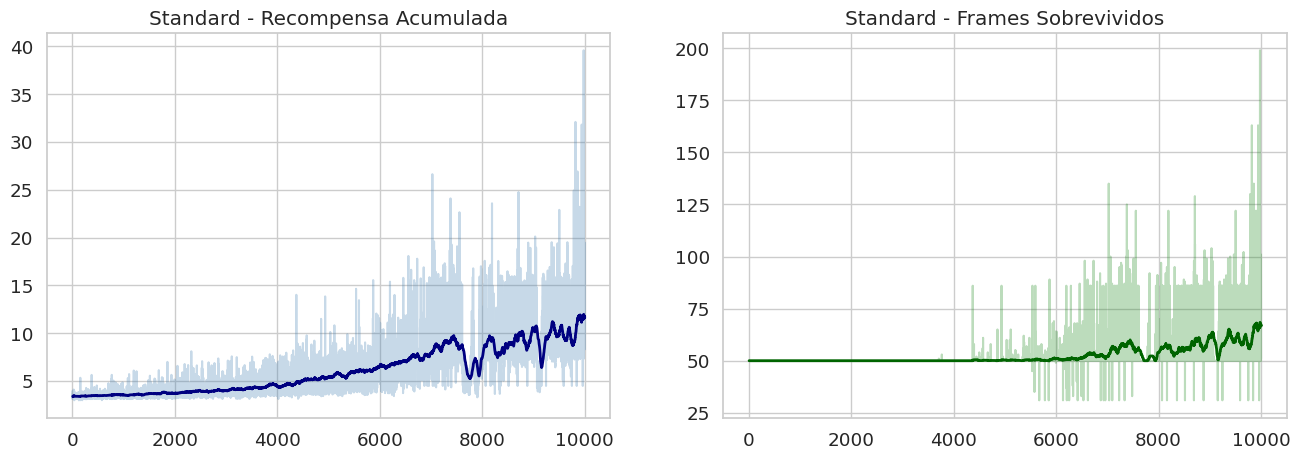

In [4]:
if not df_std.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(df_std['episode'], df_std['reward'], alpha=0.3, color='steelblue')
    ax1.plot(df_std['episode'], df_std['reward'].rolling(100, min_periods=10).mean(), color='navy', linewidth=2)
    ax1.set_title("Standard - Recompensa Acumulada")
    
    ax2.plot(df_std['episode'], df_std['steps'], alpha=0.3, color='forestgreen')
    ax2.plot(df_std['episode'], df_std['steps'].rolling(100, min_periods=10).mean(), color='darkgreen', linewidth=2)
    ax2.set_title("Standard - Frames Sobrevividos")
    plt.show()

## Parte 2: Entrenamiento SARSA Semi-Gradiente con Replay Buffer

In [5]:
env_rep = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False)
agent_rep = SemiGradientSarsaAgent(env_rep, alpha=LEARNING_RATE, gamma=GAMMA, epsilon=EPSILON_START, hidden_dim=64)
replay_buffer = ReplayBuffer(capacity=BUFFER_CAPACITY, state_dim=12)
metrics_rep = []

if TRAIN_REPLAY:
    print(f"Iniciando entrenamiento REPLAY BUFFER: {NUM_EPISODES} episodios...")
    start_time = time.time()
    
    for episode in range(NUM_EPISODES):
        state, _ = env_rep.reset()
        action = agent_rep.get_action(state)
        
        total_reward = 0
        steps = 0
        total_loss = 0.0
        updates = 0
        done = False
        
        decay_rate = max(0, (EPSILON_START - EPSILON_END) / EPSILON_DECAY_EPISODES)
        agent_rep.epsilon = max(EPSILON_END, EPSILON_START - decay_rate * episode)

        while not done:
            next_state, reward, terminated, truncated, info = env_rep.step(action)
            done = terminated or truncated
            
            next_action = agent_rep.get_action(next_state) if not done else 0
            replay_buffer.add(state, action, reward, next_state, next_action, done)
            
            if len(replay_buffer) > MIN_BUFFER_SIZE:
                b_states, b_actions, b_rewards, b_next_states, b_next_actions, b_dones = replay_buffer.sample(BATCH_SIZE)
                loss = agent_rep.update_batch(b_states, b_actions, b_rewards, b_next_states, b_next_actions, b_dones)
                total_loss += loss
                updates += 1
                
            state = next_state
            action = next_action
            
            total_reward += reward
            steps += 1
            
        metrics_rep.append({
            "episode": episode + 1,
            "reward": total_reward,
            "steps": steps,
            "epsilon": agent_rep.epsilon,
            "avg_loss": total_loss / updates if updates > 0 else 0
        })
        
        if (episode + 1) % 500 == 0:
            print(f"[Ep: {episode+1}/{NUM_EPISODES}] | Recompensa: {total_reward:6.1f} | Frames: {steps:4d} | Epsilon: {agent_rep.epsilon:.2f} | Loss: {metrics_rep[-1]['avg_loss']:.4f}")
            
    agent_rep.save_weights("models/sarsa_rep_weights.pth")
    df_rep = pd.DataFrame(metrics_rep)
    df_rep.to_csv("results/sarsa_rep_metrics.csv", index=False)
    print(f"\nEntrenamiento completado en {time.time() - start_time:.2f} segundos.\n")
else:
    print("Cargando pesos REPLAY preexistentes...")
    agent_rep.load_weights("models/sarsa_rep_weights.pth")
    if os.path.exists("results/sarsa_rep_metrics.csv"):
        df_rep = pd.read_csv("results/sarsa_rep_metrics.csv")
    else:
        df_rep = pd.DataFrame()

Iniciando entrenamiento REPLAY BUFFER: 10000 episodios...


[Ep: 500/10000] | Recompensa:    3.9 | Frames:   50 | Epsilon: 0.94 | Loss: 0.0009
[Ep: 1000/10000] | Recompensa:    3.4 | Frames:   50 | Epsilon: 0.88 | Loss: 0.0022
[Ep: 1500/10000] | Recompensa:    3.5 | Frames:   50 | Epsilon: 0.82 | Loss: 0.0048
[Ep: 2000/10000] | Recompensa:    3.5 | Frames:   50 | Epsilon: 0.76 | Loss: 0.0048
[Ep: 2500/10000] | Recompensa:    4.7 | Frames:   50 | Epsilon: 0.70 | Loss: 0.0056
[Ep: 3000/10000] | Recompensa:    6.0 | Frames:   50 | Epsilon: 0.64 | Loss: 0.0078
[Ep: 3500/10000] | Recompensa:    3.5 | Frames:   50 | Epsilon: 0.58 | Loss: 0.0086
[Ep: 4000/10000] | Recompensa:    6.2 | Frames:   50 | Epsilon: 0.53 | Loss: 0.0106
[Ep: 4500/10000] | Recompensa:    3.7 | Frames:   50 | Epsilon: 0.47 | Loss: 0.0133
[Ep: 5000/10000] | Recompensa:    5.8 | Frames:   50 | Epsilon: 0.41 | Loss: 0.0198
[Ep: 5500/10000] | Recompensa:    6.8 | Frames:   50 | Epsilon: 0.35 | Loss: 0.0231
[Ep: 6000/10000] | Recompensa:    4.3 | Frames:   50 | Epsilon: 0.29 | Loss: 

### Análisis Gráfico Replay Buffer

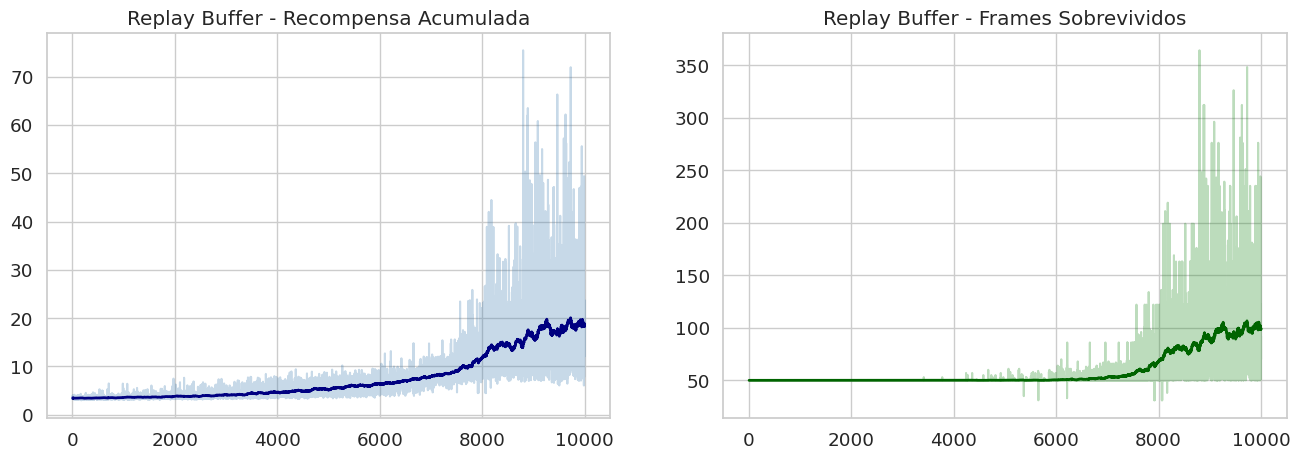

In [6]:
if not df_rep.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(df_rep['episode'], df_rep['reward'], alpha=0.3, color='steelblue')
    ax1.plot(df_rep['episode'], df_rep['reward'].rolling(100, min_periods=10).mean(), color='navy', linewidth=2)
    ax1.set_title("Replay Buffer - Recompensa Acumulada")
    
    ax2.plot(df_rep['episode'], df_rep['steps'], alpha=0.3, color='forestgreen')
    ax2.plot(df_rep['episode'], df_rep['steps'].rolling(100, min_periods=10).mean(), color='darkgreen', linewidth=2)
    ax2.set_title("Replay Buffer - Frames Sobrevividos")
    plt.show()

## Parte 3: Evaluación Lógica (Testing Greedy)

In [7]:
agent_std.epsilon = 0.0
agent_rep.epsilon = 0.0

def eval_agent(agent_env, agent_model, name):
    test_rewards, test_steps, test_scores = [], [], []
    for ep in range(NUM_TEST_EPISODES):
        state, _ = agent_env.reset()
        done, total_r, steps, score = False, 0, 0, 0
        while not done:
            action = agent_model.get_action(state)
            state, reward, terminated, truncated, info = agent_env.step(action)
            done = terminated or truncated
            total_r += reward
            steps += 1
            if done: score = info.get('score', 0)
        test_rewards.append(total_r)
        test_steps.append(steps)
        test_scores.append(score)
    print(f"\n--- RESULTADOS {name} ---")
    print(f"Supervivencia Media : {np.mean(test_steps):8.2f} frames ± {np.std(test_steps):6.2f}")
    print(f"Tuberías Superadas  : {np.mean(test_scores):8.2f} obstáculos ± {np.std(test_scores):6.2f}")

eval_agent(env, agent_std, "STANDARD SARSA")
eval_agent(env_rep, agent_rep, "REPLAY BUFFER SARSA")


--- RESULTADOS STANDARD SARSA ---
Supervivencia Media :    73.22 frames ±  19.34
Tuberías Superadas  :     0.72 obstáculos ±   0.57

--- RESULTADOS REPLAY BUFFER SARSA ---
Supervivencia Media :   971.54 frames ± 839.77
Tuberías Superadas  :    24.68 obstáculos ±  22.32


## Parte 4: Render Visual del mejor modelo (Replay Buffer)

In [8]:
try:
    env_vis = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False, render_mode="human")
except Exception as e:
    env_vis = make_flappy_bird_env(alpha=ALPHA_REWARD, use_lidar=False, render_mode=None)

evaluate_flappy_bird_agent(agent_rep, env_vis, num_episodes=NUM_RENDER_EPISODES, render=(env_vis.render_mode == "human"), fps=45)

try:
    env_vis.close()
except Exception:
    pass

[Visual-Ep 1] Agente colisionó en el timestep 651. Puntuación final: 16
[Visual-Ep 2] Agente colisionó en el timestep 214. Puntuación final: 5
[Visual-Ep 3] Agente colisionó en el timestep 348. Puntuación final: 8
